In [8]:
import os
from dotenv import load_dotenv
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [16]:
import pandas as pd
train = pd.read_csv("./data/train.csv")


In [17]:
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain_groq import ChatGroq



In [20]:
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0, api_key=GROQ_API_KEY)

agent_executor = create_pandas_dataframe_agent(
    llm,
    train,
    agent_type = 'tool-calling',
    verbose=True,
    return_intermediate_steps=False,
    allow_dangerous_code=True)


In [21]:
agent_executor.invoke("행과 열의 개수는 몇개입니까")



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'print(df.shape)'}`


(1460, 81)
The dataframe `df` has 1460 rows and 81 columns.

> Finished chain.


{'input': '행과 열의 개수는 몇개입니까',
 'output': 'The dataframe `df` has 1460 rows and 81 columns.'}



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import matplotlib.pyplot as plt\nprint(df['SalePrice'].describe())\ndf['SalePrice'].plot.hist(bins=50)\nplt.title('Histogram of House Prices')\nplt.xlabel('Price')\nplt.ylabel('Frequency')\nplt.show()"}`




Matplotlib is building the font cache; this may take a moment.


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


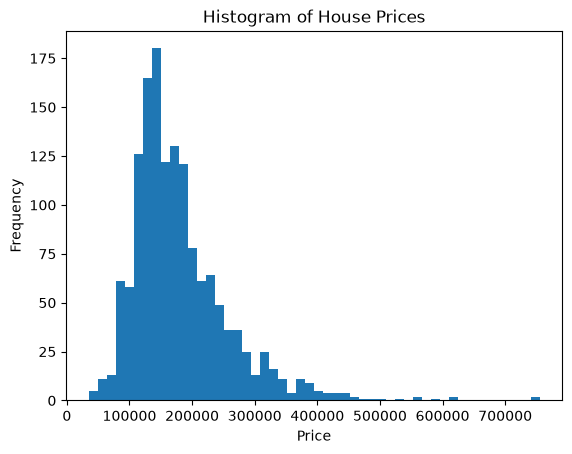

The histogram shows the distribution of house prices in the dataset. The x-axis represents the price range, and the y-axis represents the frequency of houses within each price range. The histogram provides a visual representation of the data, allowing us to see the shape of the distribution and identify any patterns or outliers.

> Finished chain.


In [26]:
response = agent_executor.invoke("주택가격 분포를 히스토그램으로 나타내줘")

In [27]:
response

{'input': '주택가격 분포를 히스토그램으로 나타내줘',
 'output': 'The histogram shows the distribution of house prices in the dataset. The x-axis represents the price range, and the y-axis represents the frequency of houses within each price range. The histogram provides a visual representation of the data, allowing us to see the shape of the distribution and identify any patterns or outliers.'}

In [28]:
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0, api_key=GROQ_API_KEY)

agent_executor = create_pandas_dataframe_agent(
    llm,
    train,
    agent_type = 'tool-calling',
    verbose=True,
    return_intermediate_steps=True,
    allow_dangerous_code=True)


In [29]:
response

{'input': '주택가격 분포를 히스토그램으로 나타내줘',
 'output': 'The histogram shows the distribution of house prices in the dataset. The x-axis represents the price range, and the y-axis represents the frequency of houses within each price range. The histogram provides a visual representation of the data, allowing us to see the shape of the distribution and identify any patterns or outliers.'}



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import matplotlib.pyplot as plt\nprint(df['SalePrice'].describe())\nplt.hist(df['SalePrice'], bins=50)\nplt.title('Histogram of SalePrice')\nplt.xlabel('SalePrice')\nplt.ylabel('Frequency')\nplt.show()"}`


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


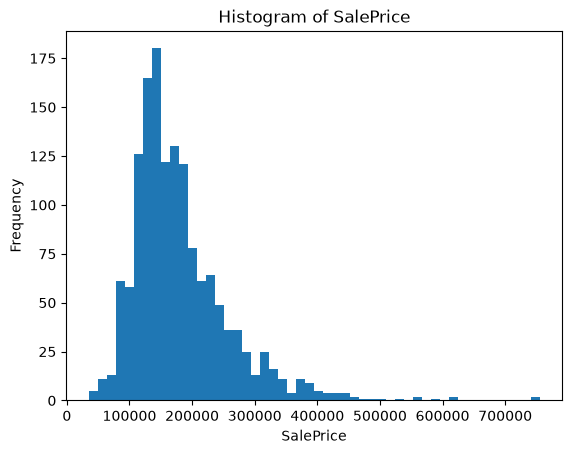

The histogram of the 'SalePrice' column in the dataframe is displayed. The histogram shows the distribution of the sale prices of the houses. The x-axis represents the sale price, and the y-axis represents the frequency of each sale price. The histogram provides a visual representation of the distribution of the sale prices, which can be useful for understanding the characteristics of the data.

> Finished chain.


In [30]:
response = agent_executor.invoke('주택가격 분포를 히스토그램으로 나타내주세요.')

In [31]:
intermediate_actions = response['intermediate_steps']
len(intermediate_actions)

1

In [33]:
intermediate_actions[0][0].tool_input['query']


"import matplotlib.pyplot as plt\nprint(df['SalePrice'].describe())\nplt.hist(df['SalePrice'], bins=50)\nplt.title('Histogram of SalePrice')\nplt.xlabel('SalePrice')\nplt.ylabel('Frequency')\nplt.show()"

In [35]:
python_code = response['intermediate_steps'][0][0].tool_input['query']
python_code

"import matplotlib.pyplot as plt\nprint(df['SalePrice'].describe())\nplt.hist(df['SalePrice'], bins=50)\nplt.title('Histogram of SalePrice')\nplt.xlabel('SalePrice')\nplt.ylabel('Frequency')\nplt.show()"

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


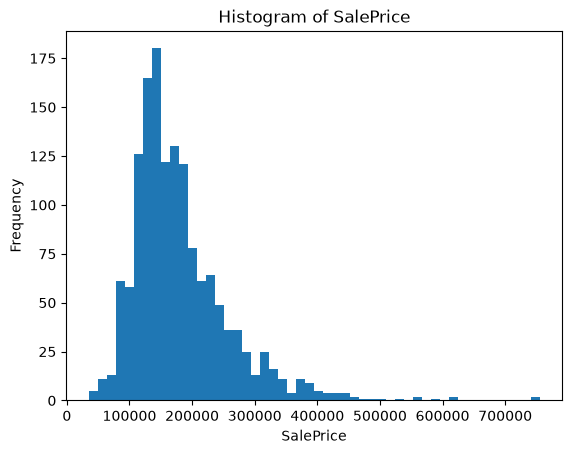

In [36]:
df = train.copy()

exec(python_code)